# MLL Project Assignment

## Business Understanding

For our project, we have chosen to utilise a dataset focusing on movie ratings from real people. The goal for our project is to create a movie recommendation algorithm, which takes ratings the user has submitted and recommending movies based on similar user's preference that align with the given ratings. In practise, this kind of system would be used by companies that host movies or series, for example a streaming service to recommend movies that cater to the user's previously rated movies.

### Goals

Create an easily usable movie recommendation model by fitting a recommendation model with our dataset and feeding it mocap data that a user would give, in this case, multiple ratings of movies that can be found under the dataset. Once fitted, the model should be able to recommend top choice that the user hasn't watched, but have been positively rated by users that have similar ratings.

### Research Questions

- Are we able to establish a link between users to indentify similar movie preferences, this recommending similar movies?
- Is user generated rating dataset able to sufficiently provide data to give accurate recommendations?
- How expansive is the movie recommendation pool, based on the categories?

## Data understanding

In this section, we import all necessary libraries and load the raw data for exploration. The two CSV files — `movies.csv` (containing movie IDs, titles, and genres) and `ratings.csv` (containing user IDs, movie IDs, ratings, and timestamps) — are loaded from the MovieLens small dataset using pandas. We then merge them on the shared `movieId` column into a single `movie_ratings` DataFrame, combining every rating record with its corresponding movie title and genre information. Finally, we display the first 10 rows to visually inspect the resulting data structure and confirm the merge was successful.

In [ ]:
import pandas as pd
import numpy as np

import time

import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Reader, Dataset
from surprise import KNNBasic, KNNWithZScore
from surprise import accuracy
from surprise import SVD
from surprise.model_selection import train_test_split, cross_validate

from collections import defaultdict

In [155]:
# Load the datasets
movies = pd.read_csv('Datasets/movies-small/ml-latest-small/movies.csv')
ratings = pd.read_csv('Datasets/movies-small/ml-latest-small/ratings.csv')

# Merging the datasets based on the movieId column
movie_ratings = pd.merge(ratings, movies, on='movieId')

# Display the first 5 rows of the merged dataset
movie_ratings.head(10)

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
5,1,70,3.0,964982400,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller
6,1,101,5.0,964980868,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance
7,1,110,4.0,964982176,Braveheart (1995),Action|Drama|War
8,1,151,5.0,964984041,Rob Roy (1995),Action|Drama|Romance|War
9,1,157,5.0,964984100,Canadian Bacon (1995),Comedy|War


## Data preparation

In this section, we clean the data, engineer a new feature, and inject simulated new-user ratings to test our recommendation model.

First, we check for duplicate rows and null values in the merged dataset — both checks confirm the data is clean with zero duplicates and zero nulls.

Next, we extract the 4-digit release year from each movie title using a regular expression, strip it from the title string, and store it as a new `year` column in the `movies` DataFrame. We then re-merge `ratings` and `movies` to produce an updated `movie_ratings` DataFrame that includes this new column.

We define a helper function `create_new_user_ratings` to reduce code duplication when creating simulated users. Using this function, we create two new users with hand-picked movie ratings:
- **User 1** rates 16 modern action/sci-fi/thriller films (e.g., Blade Runner 2049, John Wick: Chapter Two, Get Out, Deadpool).
- **User 2** rates 12 films spanning animated Batman movies, classic horror, and Harry Potter.

Each new user's ratings are enriched with movie metadata via a left join, and both are concatenated into the main `movie_ratings` DataFrame in a single operation. We then display each new user's ratings to verify they were added correctly.

In [156]:
duplicates = movie_ratings.duplicated().sum()
print("Amount of duplicates:\n",duplicates)

Amount of duplicates:
 0


In [157]:
null_values = movie_ratings.isnull().sum()
print("Null values in each column:\n", null_values)


Null values in each column:
 userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64


In [158]:
year_str = movies['title'].str.extract(r'\((\d{4})\)', expand=False)
movies['title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)
movies['year'] = pd.to_numeric(year_str, errors='coerce').astype('Int64')

movie_ratings = pd.merge(ratings, movies, on='movieId')

movie_ratings.head(10)

,userId,movieId,rating,timestamp,title,genres,year
0,1,1,4.0,964982703,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995
1,1,3,4.0,964981247,Grumpier Old Men,Comedy|Romance,1995
2,1,6,4.0,964982224,Heat,Action|Crime|Thriller,1995
3,1,47,5.0,964983815,Seven (a.k.a. Se7en),Mystery|Thriller,1995
4,1,50,5.0,964982931,"Usual Suspects, The",Crime|Mystery|Thriller,1995
5,1,70,3.0,964982400,From Dusk Till Dawn,Action|Comedy|Horror|Thriller,1996
6,1,101,5.0,964980868,Bottle Rocket,Adventure|Comedy|Crime|Romance,1996
7,1,110,4.0,964982176,Braveheart,Action|Drama|War,1995
8,1,151,5.0,964984041,Rob Roy,Action|Drama|Romance|War,1995
9,1,157,5.0,964984100,Canadian Bacon,Comedy|War,1995


In [159]:
def create_new_user_ratings(user_id, movie_ids, ratings_list):
    return pd.DataFrame({
        'userId': [user_id] * len(movie_ids),
        'movieId': movie_ids,
        'rating': ratings_list,
        'timestamp': [int(time.time())] * len(movie_ids)
    })

In [160]:
new_user_id = movie_ratings['userId'].max() + 1

new_ratings = create_new_user_ratings(new_user_id,
    [
        188301, # Ant-Man and the Wasp (2018)
        187595, # Solo: A Star Wars Story (2018)
        185029, # A Quiet Place (2018)
        184471, # Tomb Raider (2018)
        176371, # Blade Runner 2049 (2017)
        175303, # It (2017)
        168250, # Get Out (2017)
        168248, # John Wick: Chapter Two (2017)
        167370, # Assassin's Creed (2016)
        166528, # Rogue One: A Star Wars Story (2016)
        166024, # Whiplash (2013)
        163645, # Hacksaw Ridge (2016)
        161131, # War Dogs (2016)
        139385, # The Revenant (2015)
        122916, # Thor: Ragnarok (2017)
        122904, # Deadpool (2016)
    ],
    [
        2.75, # Ant-Man and the Wasp (2018)
        4.0, # Solo: A Star Wars Story (2018)
        4.8, # A Quiet Place (2018)
        3.75, # Tomb Raider (2018)
        5.0, # Blade Runner 2049 (2017)
        3.90, # It (2017)
        4.5, # Get Out (2017)
        4.75, # John Wick: Chapter Two (2017)
        1.75, # Assassin's Creed (2016)
        3.75, # Rogue One: A Star Wars Story (2016)
        4.95, # Whiplash (2013)
        4.85, # Hacksaw Ridge (2016)
        4.75, # War Dogs (2016)
        4.25, # The Revenant (2015)
        3.80, # Thor: Ragnarok (2017)
        4.0, # Deadpool (2016)
    ]
)

new_user_id2 = movie_ratings['userId'].max() + 2

new_ratings2 = create_new_user_ratings(new_user_id2,
    [
        3213, # Batman Mask of the Phantasm (1993)
        27311, # Batman Beyond: Return of the Joker (2000)
        98124, # Batman: The Dark Knight Returns, Part 1 (2012)
        99813, # Batman: The Dark Knight Returns, Part 2 (2013)
        113278, # Batman Assault on Arkham (2014)
        161354, # Batman The Killing Joke (2016)
        1347, # Nightmare on Elm Street (1984)
        1970, # Nightmare on Elm Street 3: Dream Warriors (1987)
        1991, # Child's Play (1988)
        6615, # Freddy vs. Jason (2003)
        81834, # Harry Potter and the Deathly Hallows: Part 1 (2010)
        88125, # Harry Potter and the Deathly Hallows: Part 2 (2011)
    ],
    [
        5.0, # Batman Mask of the Phantasm (1993)
        4.0, # Batman Beyond: Return of the Joker (2000)
        4.5, # Batman: The Dark Knight Returns, Part 1 (2012)
        5.0, # Batman: The Dark Knight Returns, Part 2 (2013)
        2.0, # Batman Assault on Arkham (2014)
        4.0, # Batman The Killing Joke (2016)
        3.0, # Nightmare on Elm Street (1984)
        1.0, # Nightmare on Elm Street 3: Dream Warriors (1987)
        4.0, # Child's Play (1988)
        4.0, # Freddy vs. Jason (2003)
        4.5, # Harry Potter and the Deathly Hallows: Part 1 (2010)
        4.75, # Harry Potter and the Deathly Hallows: Part 2 (2011)
    ]
)

In [161]:
movie_cols = ['movieId', 'title', 'genres', 'year']
new_ratings = pd.merge(new_ratings, movies[movie_cols], on='movieId', how='left')
new_ratings2 = pd.merge(new_ratings2, movies[movie_cols], on='movieId', how='left')

movie_ratings = pd.concat([movie_ratings, new_ratings, new_ratings2], ignore_index=True)


In [162]:
new_user_ratings = movie_ratings[movie_ratings['userId'] == new_user_id][['userId', 'movieId', 'title', 'rating']]
new_user_ratings

,userId,movieId,title,rating
100836,611,188301,Ant-Man and the Wasp,2.75
100837,611,187595,Solo: A Star Wars Story,4.00
100838,611,185029,A Quiet Place,4.80
100839,611,184471,Tomb Raider,3.75
100840,611,176371,Blade Runner 2049,5.00
100841,611,175303,It,3.90
100842,611,168250,Get Out,4.50
100843,611,168248,John Wick: Chapter Two,4.75
100844,611,167370,Assassin's Creed,1.75
100845,611,166528,Rogue One: A Star Wars Story,3.75


In [163]:
new_user_ratings2 = movie_ratings[movie_ratings['userId'] == new_user_id2][['userId', 'movieId', 'title', 'rating']]
new_user_ratings2

,userId,movieId,title,rating
100852,612,3213,Batman: Mask of the Phantasm,5.00
100853,612,27311,Batman Beyond: Return of the Joker,4.00
100854,612,98124,"Batman: The Dark Knight Returns, Part 1",4.50
100855,612,99813,"Batman: The Dark Knight Returns, Part 2",5.00
100856,612,113278,Batman: Assault on Arkham,2.00
100857,612,161354,Batman: The Killing Joke,4.00
100858,612,1347,"Nightmare on Elm Street, A",3.00
100859,612,1970,"Nightmare on Elm Street 3: Dream Warriors, A",1.00
100860,612,1991,Child's Play,4.00
100861,612,6615,Freddy vs. Jason,4.00


## Modeling

In this section, we configure and train the collaborative filtering model using the Surprise library.

We create a `Reader` object specifying the rating scale (0.5 to 5.0) and load the relevant columns (`userId`, `movieId`, `rating`) from our `movie_ratings` DataFrame into a Surprise `Dataset`.

We configure the similarity options to use **cosine similarity** with a **user-based** approach — meaning the model finds users with similar rating patterns and predicts ratings based on what those similar users liked.

The full dataset is converted into a training set using `build_full_trainset()`, and we instantiate a **KNNWithZScore** model. This algorithm improves on basic KNN by normalizing each user's ratings by both their **mean** and **standard deviation** before computing predictions. This accounts for the fact that different users rate on different scales — a "generous" rater who averages 4.5 is treated differently from a "harsh" rater who averages 2.5. The model is then fitted on the full training set, computing the cosine similarity matrix between all users.

In [164]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(movie_ratings[['userId', 'movieId', 'rating']], reader)

sim_options = {
    'name': 'cosine',
    'user_based': True,
}

final_trainset = data.build_full_trainset()
final_model = KNNWithZScore(sim_options=sim_options)
final_model.fit(final_trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


## Evaluation

In this section, we evaluate the model's performance using cross-validation and visualize the distribution of predicted ratings.

First, we run **5-fold cross-validation** using a `KNNBasic` model with the same cosine/user-based similarity settings. This splits the data into 5 subsets, trains on 4 and tests on 1 for each fold, measuring **RMSE** (Root Mean Squared Error) and **MAE** (Mean Absolute Error) — two standard metrics for rating prediction accuracy. Lower values indicate better performance.

Next, we use the trained `final_model` (KNNWithZScore) to generate predictions on the full training set. While this is an in-sample evaluation (not out-of-sample), it allows us to examine the overall distribution of the model's predicted ratings. We plot this distribution as a **histogram with a KDE curve**, showing how the model's predictions are spread across the rating scale.

In [165]:
cv_results = cross_validate(
    KNNBasic(sim_options=sim_options),
    data,
    measures=['RMSE', 'MAE'],
    cv=5,
    verbose=True
)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9669  0.9814  0.9641  0.9725  0.9804  0.9731  0.0070  
MAE (testset)     0.7468  0.7532  0.7449  0.7489  0.7509  0.7490  0.0029  
Fit time          0.74    0.50    0.33    0.35    0.31    0.45    0.16    
Test time         1.04    0.98    1.16    0.93    0.91    1.01    0.09    


In [166]:
testset_full = final_trainset.build_testset()
full_predictions = final_model.test(testset_full)

estimated_ratings = [p.est for p in full_predictions]

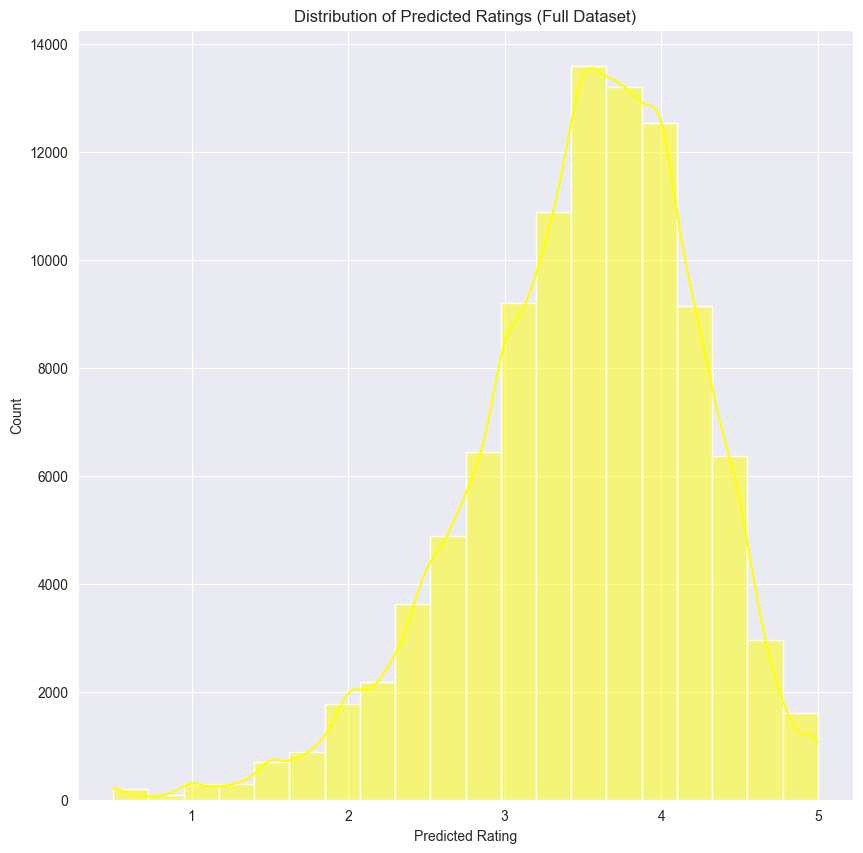

In [167]:
plt.figure(figsize=(10, 10))
sns.histplot(estimated_ratings, bins=20, kde=True, color='yellow')
plt.title('Distribution of Predicted Ratings (Full Dataset)')
plt.xlabel('Predicted Rating')
plt.ylabel('Count')
plt.show()

## Deployment

In this section, we demonstrate the recommendation system in action by generating predictions for a simulated new user.

First, we make a **single prediction** for a specific user–movie pair to inspect the model's output in detail, including the number of nearest neighbors (`actual_k`) that contributed to the prediction.

Then, we generate **top-N movie recommendations** for the new user:
1. We identify all movies the user has **already rated** and exclude them from prediction — we only want to recommend unseen movies.
2. We run `final_model.predict()` for every unrated movie in the dataset.
3. We sort predictions by estimated rating in descending order and select the top 5.
4. We use a pre-built dictionary for efficient movie title lookups and print the final recommendations with their predicted ratings.

In [168]:
user_id = new_user_id2
item_id = 1979
pred = final_model.predict(user_id, item_id, verbose=True)

user: 612        item: 1979       r_ui = None   est = 4.49   {'actual_k': 3, 'was_impossible': False}


In [169]:
rated_movie_ids = set(
    movie_ratings[movie_ratings['userId'] == new_user_id2]['movieId']
)

movie_ids = movie_ratings['movieId'].unique()
unrated_movie_ids = [mid for mid in movie_ids if mid not in rated_movie_ids]

predictions = [final_model.predict(new_user_id2, mid) for mid in unrated_movie_ids]
predictions.sort(key=lambda x: x.est, reverse=True)

top_recommendations = predictions[:5]

movie_title_lookup = movies.set_index('movieId')['title'].to_dict()
for pred in top_recommendations:
    movie_title = movie_title_lookup[pred.iid]
    print(f"{movie_title} (Predicted rating: {pred.est:.2f})")

Wallace & Gromit: The Best of Aardman Animation (Predicted rating: 5.00)
Eat Drink Man Woman (Yin shi nan nu) (Predicted rating: 5.00)
Wild Bunch, The (Predicted rating: 5.00)
Notorious (Predicted rating: 5.00)
12 Angry Men (Predicted rating: 5.00)


Yes, we successfully established links between users using **user-based collaborative filtering** with **cosine similarity** via the Surprise library's `KNNWithZScore` algorithm. The model computes a cosine similarity matrix between all users based on their rating patterns, and then identifies the most similar users (nearest neighbors) to generate predictions for unseen movies.

However, the link between users proved to be relatively weak for our simulated new users. When predicting a single movie for our second new user, the model found only **3 nearest neighbors** (`actual_k: 3`), which indicates very limited overlap between our new user's rated movies and those rated by existing users in the dataset. This is expected: our new users rated niche or recent titles (animated Batman films, horror classics, Harry Potter), which have fewer ratings in the MovieLens small dataset compared to popular mainstream films. Despite this sparsity, the model was still able to identify similar users and produce predictions.


The dataset provides a reasonable foundation, but with notable limitations. Our 5-fold cross-validation using `KNNBasic` produced a **mean RMSE of 0.9731** and a **mean MAE of 0.7490** across the full dataset. These values indicate that, on average, predicted ratings deviate from actual ratings by approximately 0.75–0.97 points on the 0.5–5.0 scale — a moderate level of accuracy.

However, the results deteriorate significantly for new users with few ratings. Our simulated users had only 12–16 ratings each, and the model often found very few neighbors (`actual_k: 3`), leading to predictions that are heavily influenced by a tiny number of similar users. This is reflected in the top-5 recommendations, where all five movies received a predicted rating of exactly **5.00** — suggesting the model lacks the data to differentiate between recommendations for sparse users. In summary, the user-generated dataset is sufficient for users with many ratings, but struggles to provide nuanced recommendations for users with limited rating history. A larger dataset or a more robust algorithm (e.g., SVD) could improve results for cold-start users.

The recommendation pool is relatively expansive in terms of genre diversity. Our second new user primarily rated **animated superhero films** (Batman), **horror** (Nightmare on Elm Street, Child's Play, Freddy vs. Jason), and **fantasy** (Harry Potter). However, the top-5 recommendations the model produced were:

1. **Wallace & Gromit: The Best of Aardman Animation** — Animation/Comedy
2. **Eat Drink Man Woman** — Comedy/Drama
3. **Wild Bunch, The** — Western/Action
4. **Notorious** — Film-Noir/Romance/Thriller
5. **12 Angry Men** — Drama

These span a wide range of genres (animation, comedy, drama, western, film-noir, thriller) that largely differ from the user's input genres. This demonstrates that user-based collaborative filtering recommends based on **what similar users enjoyed**, not simply on matching genres. The recommendation pool is therefore not limited to the user's existing preferences — it can surface unexpected discoveries across the full breadth of the dataset's ~9,700 movies. That said, this diversity may also be a sign that the model had too few neighbors to produce focused recommendations, defaulting to generally highly-rated films rather than genre-specific ones.